# **Regression:**
## **LinearRegression:**
# **Mean square value:**

In [8]:
import numpy as np
#Datause
x=np.array([1,2,3,4])
y=np.array([3,4,5,6])
#initial values
m=0
b=0
learning_rate=0.01
epochs=1000
n=len(x)
for i in range(epochs):
    #Prediction
    y_pred=m*x+b
    #Gradients
    dm=(-2/n)*np.sum(x*(y-y_pred))
    db=(-2/n)*np.sum(y-y_pred)
    #Update parameters
    m=m-learning_rate*dm
    b=b-learning_rate*db
print("Slope(m):",m)
print("Intercept(b):",b)

Slope(m): 1.0252338988181484
Intercept(b): 1.9258092602843162


# **OLS(Ordinary Least Squared):**
### predict values using lines,compare prect value with actuall value,find the error,square all errors,add then together,choose the line with similar line error

In [9]:
import pandas as pd
from sklearn.linear_model import LinearRegression
#Sample Data 
df=pd.DataFrame({
    'Experience':[1,2,3,4,5],
    'Salary':[30000,35000,40000,45000,50000]
})
#Input Feature(x)
x=df[['Experience']]
#Target Variable(y)
y=df['Salary']
#Create Model
model=LinearRegression()
#Train Model(ORL)
model.fit(x,y)
#Predict Salary
predictions=model.predict(x)
#Results
print('Slope:',model.coef_[0])
print('Intercept:',model.intercept_)
print('Predicted Salaries:',predictions)


#New Experience
new_experience=pd.DataFrame({
    'Experience':[6,7,8,9,10]
})
#Predict salary for new values
new_prediction=model.predict(new_experience)
print('Predicted Salary for 6,7,8,9,10')
print(new_prediction)

Slope: 5000.000000000001
Intercept: 24999.999999999996
Predicted Salaries: [30000. 35000. 40000. 45000. 50000.]
Predicted Salary for 6,7,8,9,10
[55000. 60000. 65000. 70000. 75000.]


# **Scatter Plot:**

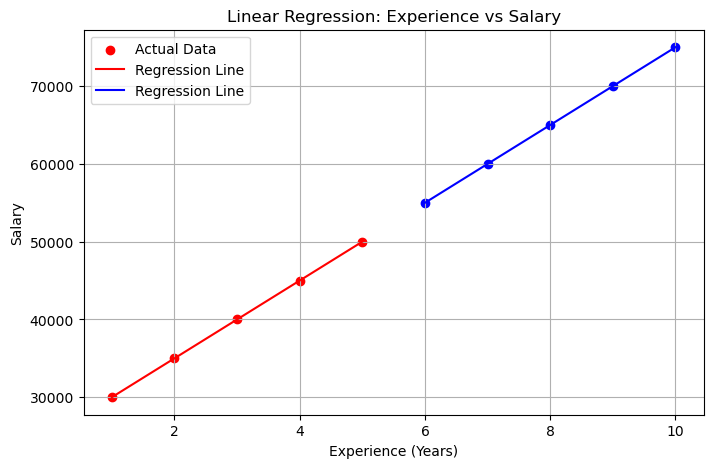

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
# Original data points
plt.scatter(df['Experience'], df['Salary'], color='red', label='Actual Data')
# Regression line (trained data)
plt.plot(df['Experience'], predictions, color='red', label='Regression Line')
# New predictions
plt.scatter(new_experience['Experience'], new_prediction, color='blue')
plt.plot(new_experience['Experience'], new_prediction, color='blue', label='Regression Line')
# Labels
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.title("Linear Regression: Experience vs Salary")
plt.legend()
plt.grid()
plt.show()

## **Multiple Regression:**
### Uses two or more independent variable to predict a dependent variable

In [11]:
import pandas as pd
from sklearn.linear_model import LinearRegression
#Dataset
df=pd.DataFrame({
    'Area':[1000,2000,3000,4000,5000],
    'Bedrooms':[1,2,3,4,1],
    'Age':[1,21,13,4,5],
    'Price':[200000,300000,400000,500000,600000]
})
# Features
x=df[['Area','Bedrooms','Age']]   #Using multiple features.
#Target
y = df['Price']
#Model
model = LinearRegression()
#Train
model.fit(x,y)   #Learns the relationship between all features and price.
#Prediction
pred = model.predict(x) #predict house price
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print(pred)

Coefficients: [ 1.00000000e+02 -1.95160831e-12 -8.35575365e-13]
Intercept: 99999.99999999988
[200000. 300000. 400000. 500000. 600000.]


# **MultiCollinearity:**

In [12]:
#VIF Code
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
#Features
x=df[['Area','Bedrooms','Age']]
#VIF Calculation
vif = pd.DataFrame()
vif['Feature']=x.columns
vif['VIF']=[
    variance_inflation_factor(x.values,i)
    for i in range(x.shape[1])
]
print(vif)

    Feature       VIF
0      Area  3.585739
1  Bedrooms  4.363058
2       Age  2.124701


# **Polynomial Regression:**

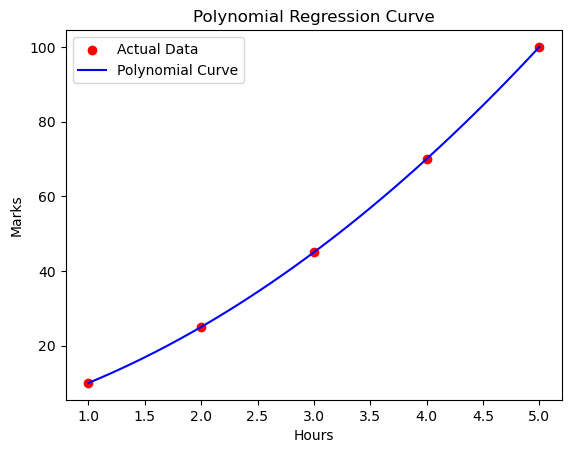

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
#Sample dataset
df = pd.DataFrame({
    'Hours':[1, 2, 3, 4, 5],
    'Marks':[10, 25, 45, 70, 100]
})
x=df[['Hours']]
y=df['Marks']
#Polynomial transformation
poly = PolynomialFeatures(degree=4)
x_poly = poly.fit_transform(x)
#Model training
model = LinearRegression()
model.fit(x_poly, y)
#Smooth curve generation (IMPORTANT STEP)
x_range = np.linspace(x.min(),x.max(), 100).reshape(-1, 1)
x_range = pd.DataFrame(x_range, columns=['Hours'])
x_range_poly = poly.transform(x_range)
#Predictions for curve
y_curve = model.predict(x_range_poly)
#Plotting
plt.scatter(x, y, color='red', label='Actual Data')
plt.plot(x_range, y_curve, color='blue', label='Polynomial Curve')
plt.title('Polynomial Regression Curve')
plt.xlabel('Hours')
plt.ylabel('Marks')
plt.legend()
plt.show()

# **Underfit Bestfit and Overfit:**

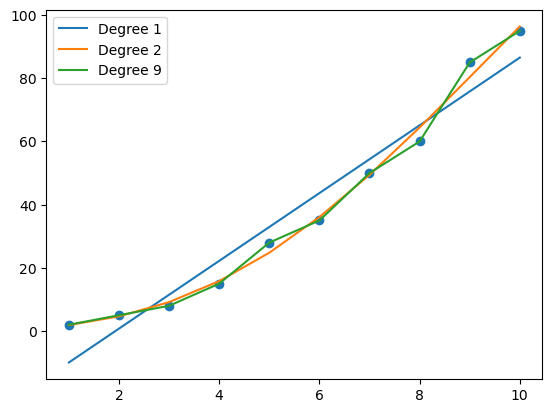

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
X = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y = np.array([2,5,8,15,28,35,50,60,85,95])
# Degree 1
poly1 = PolynomialFeatures(degree=1)
X1 =poly1.fit_transform(X)
# Degree 2
poly4 = PolynomialFeatures(degree=4)
X4 =poly4.fit_transform(X)
# Degree 9
poly9 = PolynomialFeatures(degree=9)
X9 =poly9.fit_transform(X)
model1 = LinearRegression().fit(X1,y)
model2 = LinearRegression().fit(X4,y)
model9 = LinearRegression().fit(X9,y)
plt.scatter(X,y)
plt.plot(X, model1.predict(X1), label="Degree 1")
plt.plot(X, model2.predict(X4), label="Degree 2")
plt.plot(X, model9.predict(X9), label="Degree 9")
plt.legend()
plt.show()

# **Regularization:**

In [3]:
##Ridge Code
from sklearn.linear_model import Ridge
from sklearn.datasets import make_regression
X, y = make_regression(
    n_samples=100,
    n_features=5,
    noise=20,
    random_state=42
)
ridge = Ridge(alpha=1.0)
ridge.fit(X, y)
print("Coefficients:")
print(ridge.coef_)

Coefficients:
[62.4844981  98.07649112 57.01070157 52.31272567 35.35343002]


# **Lasso:**

In [13]:
##Lasso Code
from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
X, y = make_regression(
    n_samples=100,
    n_features=10,
    noise=20,
    random_state=42
)
lasso = Lasso(alpha=7.0)
lasso.fit(X, y)
print("Coefficients:")
print(lasso.coef_)

Coefficients:
[12.79469118 49.78817806  0.         57.20114055 84.19587616 64.79250251
 76.56966898  0.          0.         62.40689859]


# **ElasticNet Code:**

In [17]:
##ElasticNet Code
from sklearn.linear_model import ElasticNet
from sklearn.datasets import make_regression
X, y = make_regression(
    n_samples=100,
    n_features=10,
    noise=20,
    random_state=42
)
elastic = ElasticNet(
    alpha=3.0,                     #values=0.01 to 1.0 range only in ratio
    l1_ratio=0.95
)
elastic.fit(X, y)
print("Coefficients:")
print(elastic.coef_)

Coefficients:
[16.78147735 46.95345563  0.         52.75220681 75.67517581 62.26740823
 70.92777514 -0.          3.65146606 56.51537141]
